SEASONAL NAIVE BASELINE (12-month holdout)
MAE : 31,354.17
RMSE: 33,714.22


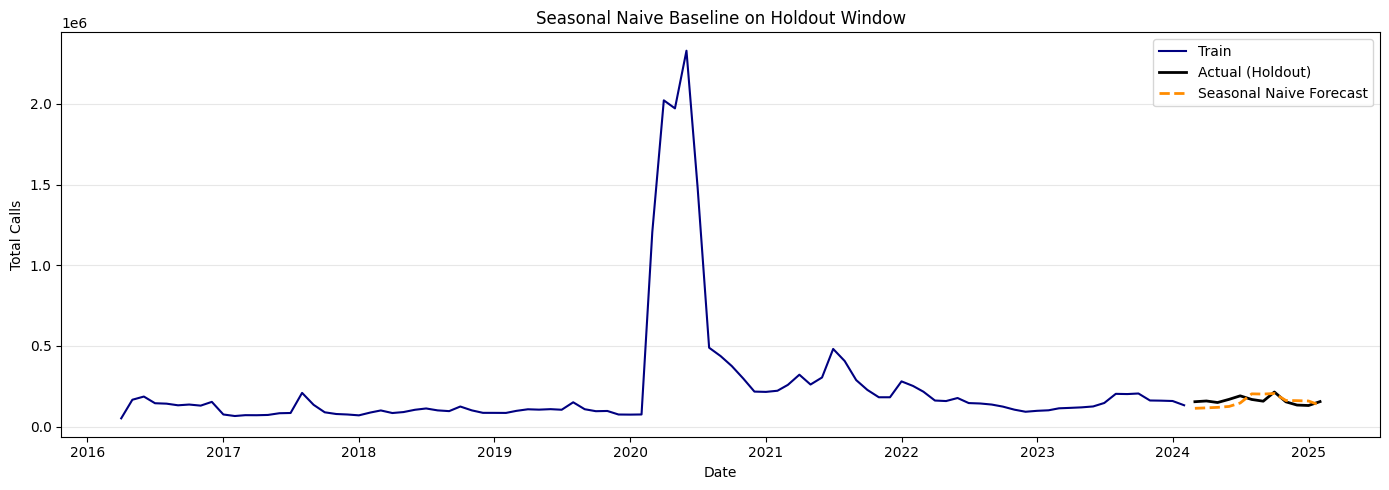

In [ ]:
# Seasonal naive baseline using a 12-month holdout window
holdout_periods = 12
train = total_calls.iloc[:-holdout_periods]
test = total_calls.iloc[-holdout_periods:]

seasonal_naive_forecast = total_calls.shift(12).reindex(test.index)
eval_df = pd.DataFrame({
    'actual': test,
    'seasonal_naive': seasonal_naive_forecast
}).dropna()

mae = np.mean(np.abs(eval_df['actual'] - eval_df['seasonal_naive']))
rmse = np.sqrt(np.mean((eval_df['actual'] - eval_df['seasonal_naive']) ** 2))

print('SEASONAL NAIVE BASELINE (12-month holdout)')
print(f'MAE : {mae:,.2f}')
print(f'RMSE: {rmse:,.2f}')

plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label='Train', color='navy')
plt.plot(test.index, test, label='Actual (Holdout)', color='black', linewidth=2)
plt.plot(eval_df.index, eval_df['seasonal_naive'], label='Seasonal Naive Forecast', color='darkorange', linestyle='--', linewidth=2)
plt.title('Seasonal Naive Baseline on Holdout Window')
plt.xlabel('Date')
plt.ylabel('Total Calls')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()